In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import ResNet50V2

In [2]:
# Load CSV file with image labels
data_path = r"E:\Junaed_Jibon\Model_Training\updated_train_dataset.csv"
image_dir = r"E:\Junaed_Jibon\Model_Training\Train_images"

In [3]:
#Load and preprocess the dataset
data = pd.read_csv(data_path)
data['file_path'] = data['Image_Id'].apply(lambda x: os.path.join(image_dir, x))
data['label'] = data['Label'].astype(str)

In [4]:
# Parameters for image dimensions, batch size, and training epochs
img_height, img_width = 224, 224  
batch_size = 32
epochs = 25

In [5]:
# Prepare Image Data Generator
data_gen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.1111
)

train_gen = data_gen.flow_from_dataframe(
    dataframe=data,
    directory=image_dir,
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = data_gen.flow_from_dataframe(
    dataframe=data,
    directory=image_dir,
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4151 validated image filenames belonging to 8 classes.
Found 518 validated image filenames belonging to 8 classes.


In [6]:
# Load VGG19 model with pretrained weights and exclude top layer
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [7]:
# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5 )(x)
# Adjust the final Dense layer for the number of classes; here 8 classes are assumed.
predictions = Dense(8, activation='softmax')(x)

# Create the complete model.
model = Model(inputs=base_model.input, outputs=predictions)

In [8]:
# Compile the model with an appropriate optimizer and learning rate.
model.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Define callbacks for dynamic learning rate adjustment and early stopping.
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1,
        restore_best_weights=True
    )
]


In [10]:
#Train the Model

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_steps=val_gen.samples // batch_size,
    callbacks=callbacks
)

Epoch 1/25
129/129 [==============================] - 63s 430ms/step - loss: 1.9834 - accuracy: 0.2610 - val_loss: 1.6032 - val_accuracy: 0.4824 - lr: 1.0000e-05
Epoch 2/25
129/129 [==============================] - 55s 424ms/step - loss: 1.3522 - accuracy: 0.5484 - val_loss: 1.1255 - val_accuracy: 0.6445 - lr: 1.0000e-05
Epoch 3/25
129/129 [==============================] - 54s 418ms/step - loss: 0.9370 - accuracy: 0.7152 - val_loss: 0.8092 - val_accuracy: 0.7559 - lr: 1.0000e-05
Epoch 4/25
129/129 [==============================] - 55s 421ms/step - loss: 0.6786 - accuracy: 0.8055 - val_loss: 0.6082 - val_accuracy: 0.8242 - lr: 1.0000e-05
Epoch 5/25
129/129 [==============================] - 53s 413ms/step - loss: 0.4598 - accuracy: 0.8898 - val_loss: 0.4854 - val_accuracy: 0.8633 - lr: 1.0000e-05
Epoch 6/25
129/129 [==============================] - 54s 414ms/step - loss: 0.3056 - accuracy: 0.9374 - val_loss: 0.3963 - val_accuracy: 0.8828 - lr: 1.0000e-05
Epoch 7/25
129/129 [========

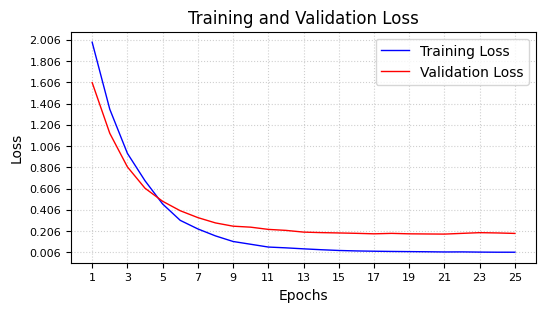

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss(history):
    # Check if history object is valid
    epochs = range(1, len(history.history['loss']) + 1)
    
    plt.figure(figsize=(6, 3))  # More horizontal layout
    
    # Plot loss curves
    plt.plot(epochs, np.array(history.history['loss']), label='Training Loss', 
             color='blue', linestyle='-', linewidth=1)
    
    if 'val_loss' in history.history:
        plt.plot(epochs, np.array(history.history['val_loss']), label='Validation Loss', 
                 color='red', linestyle='-', linewidth=1)

    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(linestyle='dotted', alpha=0.6)

    # Dynamically adjust x-axis ticks
    interval = 2 if len(epochs) <= 50 else 5
    plt.xticks(range(1, len(epochs) + 1, interval), fontsize=8)
    
    # Set y-axis dynamically based on loss values
    min_loss = min(min(history.history['loss']), min(history.history.get('val_loss', [float('inf')])))
    max_loss = max(max(history.history['loss']), max(history.history.get('val_loss', [-float('inf')])))
    plt.yticks(np.arange(min_loss, max_loss + 0.2, 0.2), fontsize=8)  

    plt.show()
    
plot_loss(history)


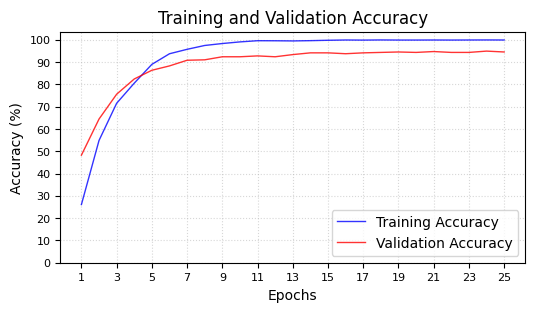

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy(history):

    epochs = range(1, len(history.history['accuracy']) + 1)
    
    plt.figure(figsize=(6, 3))  # More horizontal layout

    # Plot accuracy with a thin, smooth line to match your reference image
    plt.plot(epochs, np.array(history.history['accuracy']) * 100, label='Training Accuracy', 
             color='blue', linestyle='-', linewidth=1, alpha=0.8)
    
    if 'val_accuracy' in history.history:
        plt.plot(epochs, np.array(history.history['val_accuracy']) * 100, label='Validation Accuracy', 
                 color='red', linestyle='-', linewidth=1, alpha=0.8)

    # Labels and title
    plt.title('Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Accuracy (%)', fontsize=10)
    plt.legend(fontsize=10, loc='lower right')  
    plt.grid(linestyle='dotted', alpha=0.5)  # Softer grid lines

    # Dynamically adjust x-axis ticks
    interval = 5 if len(epochs) > 50 else 2
    plt.xticks(range(1, len(epochs) + 1, interval), fontsize=8)
    
    # Set y-axis from 0 to 100 with smooth intervals
    plt.yticks(np.arange(0, 101, 10), fontsize=8)  

    plt.show()

# Call the function correctly (no extra spaces)
plot_accuracy(history)


In [13]:
# Evaluate the model
eval_result = model.evaluate(val_gen)
print(f"Validation Loss: {eval_result[0]}, Validation Accuracy: {eval_result[1]}")

17/17 [==============================] - 7s 374ms/step - loss: 0.1743 - accuracy: 0.9479
Validation Loss: 0.17430102825164795, Validation Accuracy: 0.9478764533996582


In [14]:
# Save the model
model.save('ResNet50V2_Model.h5')